In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('/content/WineQT.csv')



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
import numpy as np



In [ ]:
X = data.drop(columns=["quality", "Id"])
y = data["quality"]

In [ ]:
# For Logistic Regression and KNN, classify quality as 'good' (1) or 'bad' (0) based on a threshold
y_binary = (y >= 6).astype(int)  # Threshold: quality >= 6 is considered good

# Split data for regression and classification tasks
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

In [ ]:
# Standardize features for models sensitive to feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_binary_scaled = scaler.fit_transform(X_train_binary)
X_test_binary_scaled = scaler.transform(X_test_binary)

In [ ]:
# Perform Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

In [ ]:
# Perform Logistic Regression
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_binary_scaled, y_train_binary)
y_pred_logistic = logistic_model.predict(X_test_binary_scaled)
logistic_accuracy = accuracy_score(y_test_binary, y_pred_logistic)

In [ ]:
# Perform K-Nearest Neighbors (KNN) Classification
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_binary_scaled, y_train_binary)
y_pred_knn = knn_model.predict(X_test_binary_scaled)
knn_accuracy = accuracy_score(y_test_binary, y_pred_knn)

# Output results
linear_rmse, logistic_accuracy, knn_accuracy, classification_report(y_test_binary, y_pred_logistic)

(0.6164677203737233,
 0.7685589519650655,
 0.7248908296943232,
 '              precision    recall  f1-score   support\n\n           0       0.74      0.75      0.74       102\n           1       0.79      0.79      0.79       127\n\n    accuracy                           0.77       229\n   macro avg       0.77      0.77      0.77       229\nweighted avg       0.77      0.77      0.77       229\n')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

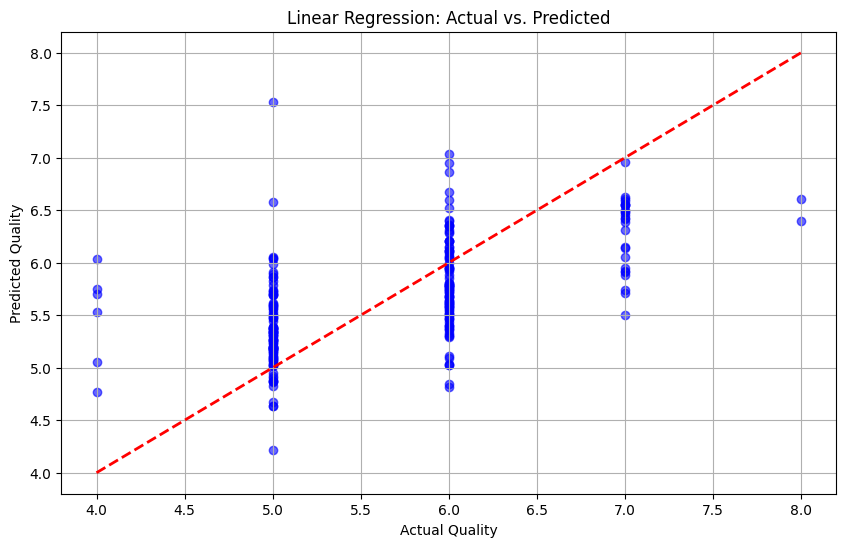

In [ ]:

# 1. Visualization for Linear Regression (Actual vs. Predicted)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", linewidth=2)
plt.title("Linear Regression: Actual vs. Predicted")
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.grid()
plt.show()

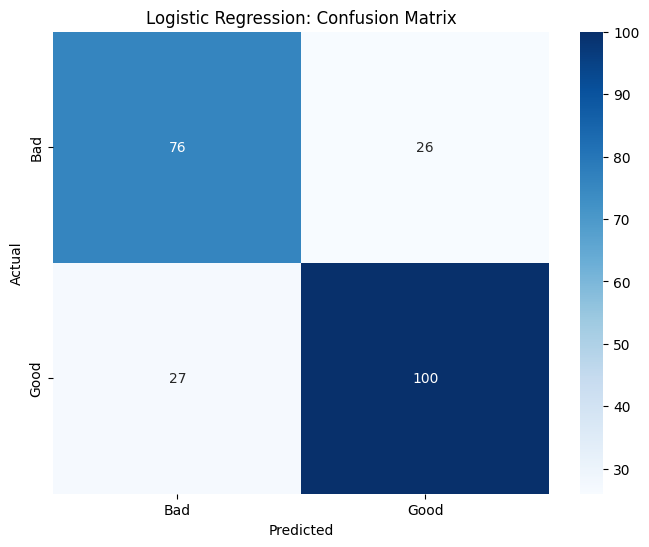

In [ ]:
# 2. Visualization for Logistic Regression (Confusion Matrix)
logistic_cm = confusion_matrix(y_test_binary, y_pred_logistic)
plt.figure(figsize=(8, 6))
sns.heatmap(logistic_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"])
plt.title("Logistic Regression: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

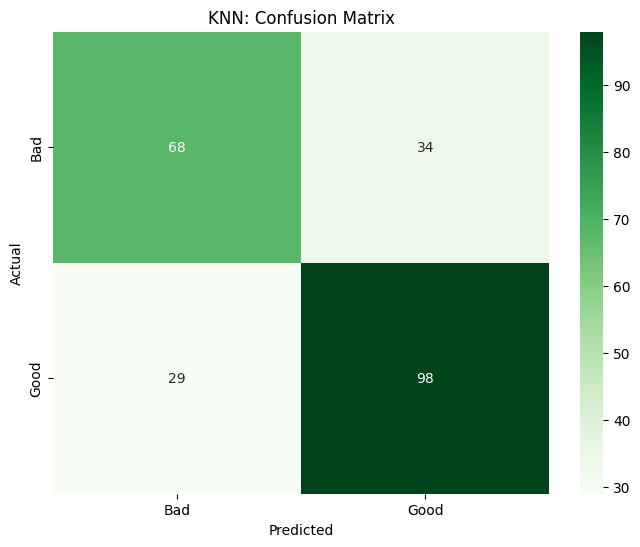

In [ ]:
# 3. Visualization for KNN (True vs. Predicted Heatmap)
knn_cm = confusion_matrix(y_test_binary, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"])
plt.title("KNN: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
